# Milestone 2: Detection Dataset Construction

This notebook builds the synthetic multi-celebrity detection dataset used to fine-tune YOLOv8 in Milestone 3. CelebA only provides single-face photos, so we create synthetic "group photos" by pasting face crops of our four celebrities onto photos of empty rooms, and label every face with a YOLO-format bounding box.

The reusable logic lives in `src/synthesize.py`; this notebook calls those functions step by step and shows the results inline.


#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (CPU also works), then run this cell. By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`. Cloning the private repo needs a GitHub personal access token saved as a Colab secret named `GITHUB_TOKEN`. Locally, the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Julia\Development\IE7615-Group3-Project1


In [5]:
# !python -m pip install torch
# !python -m pip install torchvision

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.6 MB/s eta 0:00:01
   ---------------------- ----------------- 0.8/1.4 MB 1.4 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.3 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.2 MB/s eta 0:00:00


In [6]:
import random

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

from src import synthesize as syn

print("Classes:", dict(enumerate(syn.CLASS_NAMES)))
display(pd.crosstab(syn.FACES["identity"], syn.FACES["split"])[["train", "val", "test"]])

Classes: {0: 'id_2336', 1: 'id_2970', 2: 'id_4422', 3: 'id_7007'}


split,train,val,test
identity,,,
2336,15,5,5
2970,15,5,5
4422,15,5,5
7007,14,5,5


---
## Task 1: Composition + Labels

Source faces are the 99 CelebA photos from Milestone 1, reused with the **same 60 / 20 / 20 per-identity split** (`data/splits.csv`). Every synthetic image draws its faces and its background from one split only, so no face or background appears in more than one of train, validation and test.

**YOLO folder structure**

YOLO expects `images/` and `labels/` folders for each split, with each image matched to a label file of the same name, plus a `data.yaml` listing the folders and class names. Class IDs match Milestone 1.

In [7]:
syn.setup_folders()
print((syn.DET_DIR / "data.yaml").read_text())

Created YOLO folders and data.yaml in C:\Users\Julia\Development\IE7615-Group3-Project1\data\detection
train: images/train
val: images/val
test: images/test
names:
  0: id_2336
  1: id_2970
  2: id_4422
  3: id_7007



**Part B: Face trimming**

Each CelebA photo (178 x 218) includes hair, neck and background. Before pasting, it is trimmed to the face region `FACE_BOX` (102 x 125), so the pasted patch is the face and its bounding box is tight. The green box below shows the trim region on 4 photos per identity.

FACE_BOX (left, top, right, bottom): (38, 60, 140, 185)
Saved C:\Users\Julia\Development\IE7615-Group3-Project1\results\milestone2\face_box_check.png


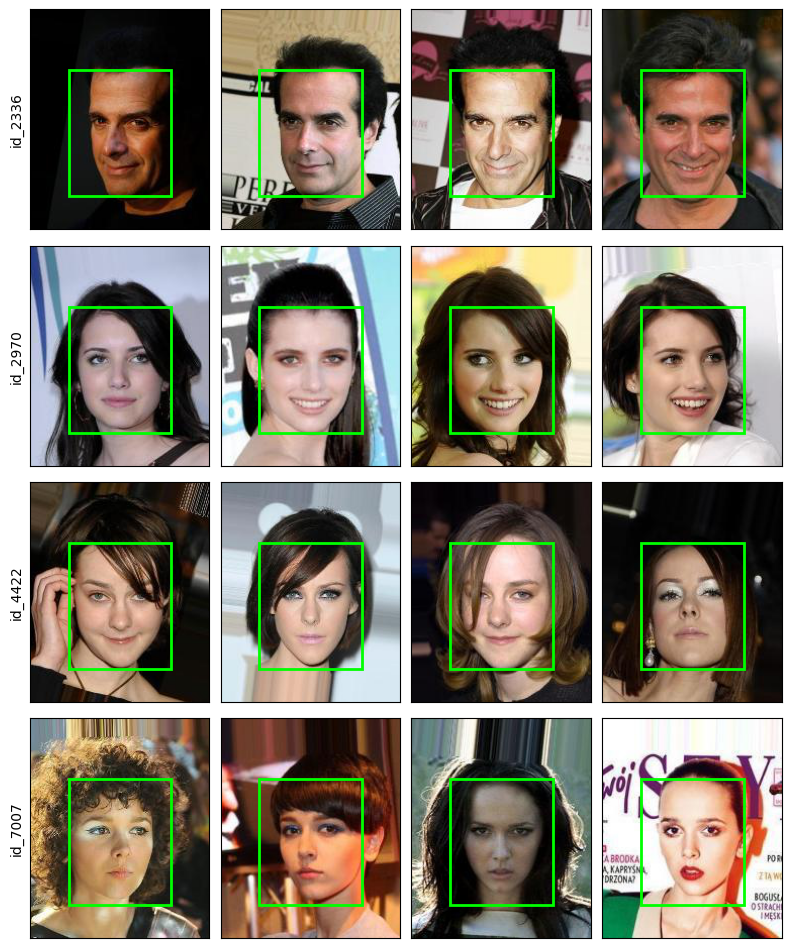

In [8]:
print("FACE_BOX (left, top, right, bottom):", syn.FACE_BOX)
syn.preview_face_box()
plt.show()

**Backgrounds**

30 openly licensed photos of empty rooms from Openverse (CC0, public domain, CC BY), resized to 640 x 640 and split 18 / 6 / 6, so test images use rooms never seen in training. No background contains a person, since an unlabelled face would teach the detector that faces are background. Sources and licenses: `data/backgrounds/SOURCES.md`.

{'train': 18, 'val': 6, 'test': 6}


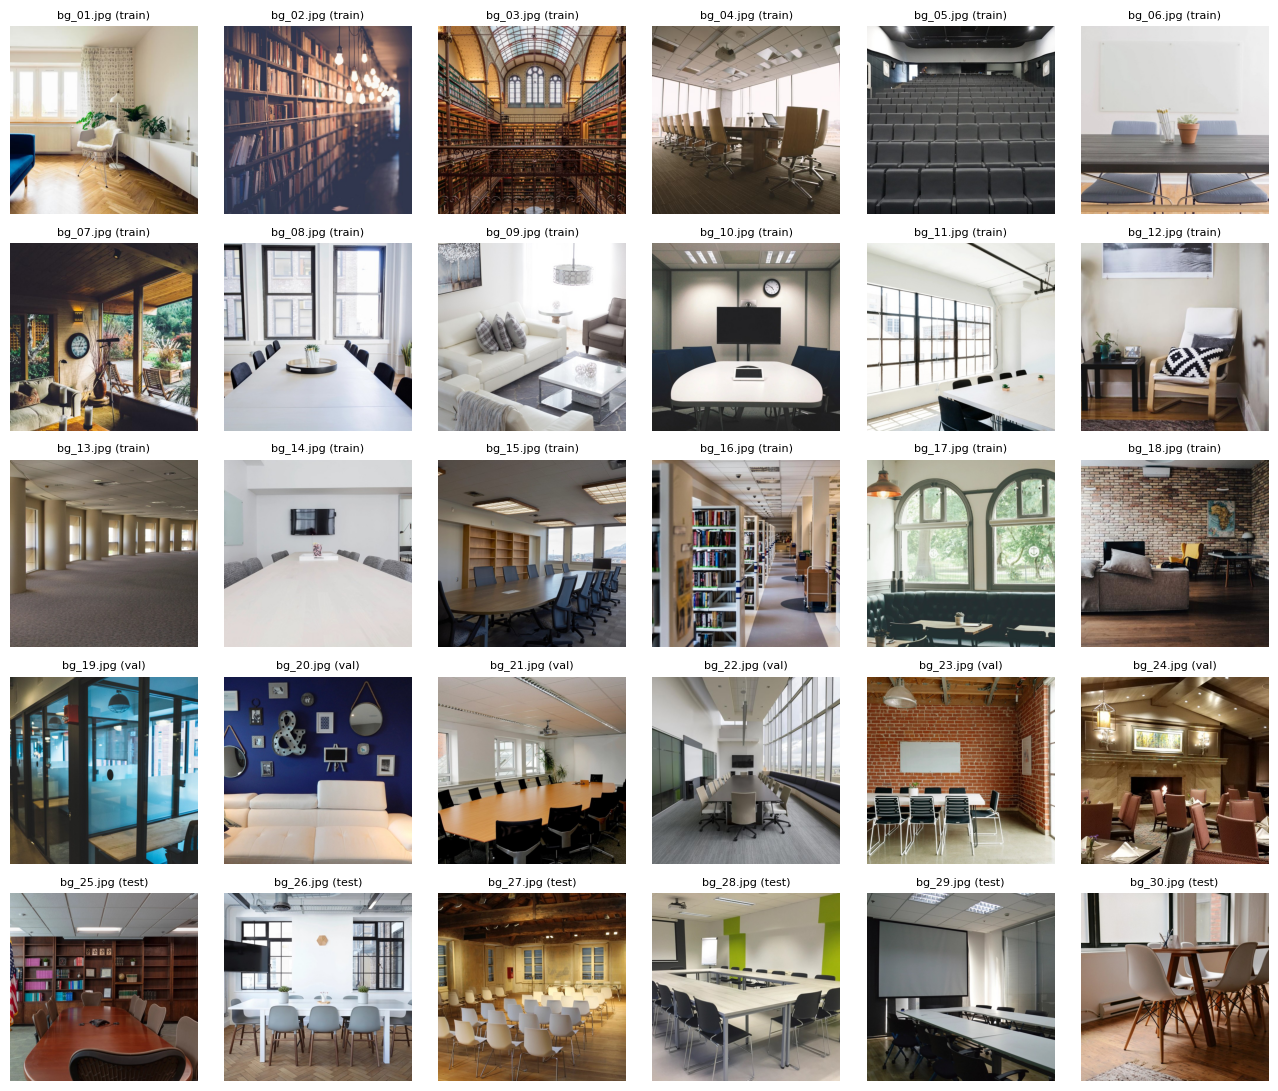

In [9]:
bg_files = [(s, f) for s in syn.SPLITS for f in sorted((syn.BG_DIR / s).glob("bg_*.jpg"))]
print(pd.Series([s for s, _ in bg_files]).value_counts()[list(syn.SPLITS)].to_dict())

fig, axes = plt.subplots(5, 6, figsize=(13, 11))
for ax in axes.flat:
    ax.axis("off")
for ax, (split, f) in zip(axes.flat, bg_files):
    ax.imshow(Image.open(f))
    ax.set_title(f"{f.name} ({split})", fontsize=8)
fig.tight_layout()
syn.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(syn.RESULTS_DIR / "backgrounds_contact_sheet.png", dpi=110, bbox_inches="tight")
plt.show()

**Composing a synthetic image**

`compose_image` pastes 2-4 **different** celebrities onto one background from the same split:
- random face height (`FACE_HEIGHT`) and brightness (`BRIGHTNESS`) for scale and lighting variation,
- random position within a head-height band (`HEAD_BAND`), with no overlapping faces,
- a soft oval blend, so faces don't come up as rectangular patches in the room.

It returns the image and each face's pixel box `(class_id, x1, y1, x2, y2)`.

Faces per image: (2, 4) | face height (px): (90, 220) | brightness: (0.7, 1.3) | head band: (0.2, 0.8)
Saved C:\Users\Julia\Development\IE7615-Group3-Project1\results\milestone2\composite_check_train.png


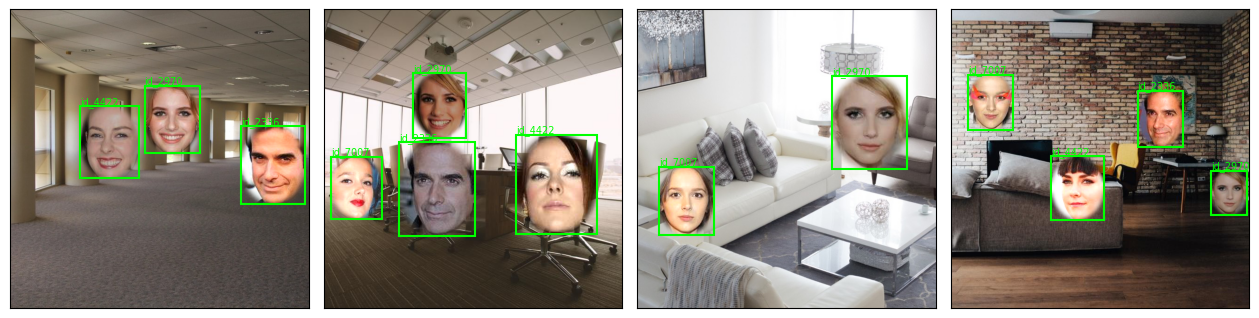

In [10]:
print("Faces per image:", syn.FACES_PER_IMAGE, "| face height (px):", syn.FACE_HEIGHT,
      "| brightness:", syn.BRIGHTNESS, "| head band:", syn.HEAD_BAND)
syn.preview_composites("train")
plt.show()

**YOLO labels**

YOLO describes each box by its center and size, divided by the image size so every value is between 0 and 1:
`class_id x_center y_center width height`. Below, one composed image's pixel boxes and the matching YOLO label lines.

In [11]:
image, boxes = syn.compose_image("train", random.Random(0))
print("Pixel boxes (class_id, x1, y1, x2, y2):")
for b in boxes:
    print(" ", b)
print("\nYOLO label lines:")
print("\n".join(syn.to_yolo(boxes)))

Pixel boxes (class_id, x1, y1, x2, y2):
  (0, 495, 250, 631, 417)
  (1, 288, 163, 406, 308)
  (2, 150, 207, 276, 361)

YOLO label lines:
0 0.879687 0.521094 0.212500 0.260937
1 0.542188 0.367969 0.184375 0.226562
2 0.332813 0.443750 0.196875 0.240625


**Generating the dataset**

300 / 100 / 100 images (60 / 20 / 20). Each split has its own fixed seed, so the dataset is fully reproducible and changing one split's size leaves the others unchanged. Files are named `<split>_<number>` (e.g. `train_0001.jpg` + `train_0001.txt`). Re-running this cell deletes the previous files first.

In [12]:
N_IMAGES = {"train": 300, "val": 100, "test": 100}
SEED = 42

rows = []
for i, (split, n) in enumerate(N_IMAGES.items()):
    rng = random.Random(SEED + i)
    img_dir = syn.DET_DIR / "images" / split
    lbl_dir = syn.DET_DIR / "labels" / split
    for old in [*img_dir.glob("*.jpg"), *lbl_dir.glob("*.txt")]:
        old.unlink()

    for k in range(1, n + 1):
        image, boxes = syn.compose_image(split, rng)
        name = f"{split}_{k:04d}"
        image.save(img_dir / f"{name}.jpg", quality=90)
        syn.write_label(boxes, lbl_dir / f"{name}.txt")
        rows += [{"split": split, "identity": syn.CLASS_NAMES[b[0]]} for b in boxes]

faces = pd.DataFrame(rows)
summary = pd.crosstab(faces["identity"], faces["split"], margins=True, margins_name="total")
summary = summary[["train", "val", "test", "total"]]
images_row = pd.DataFrame([{**N_IMAGES, "total": sum(N_IMAGES.values())}], index=["images"])
display(pd.concat([images_row, summary.rename(index={"total": "faces"})]))

,train,val,test,total
images,300,100,100,500
id_2336,226,72,76,374
id_2970,219,78,79,376
id_4422,222,75,77,374
id_7007,224,79,71,374
faces,891,304,303,1498


**Sample annotated images**

A quick check of the saved files: each sample below is read back **from disk**, and its boxes are drawn from its **label file**, converting the YOLO values back to pixels. If the boxes land on the faces, the images and labels were written correctly.

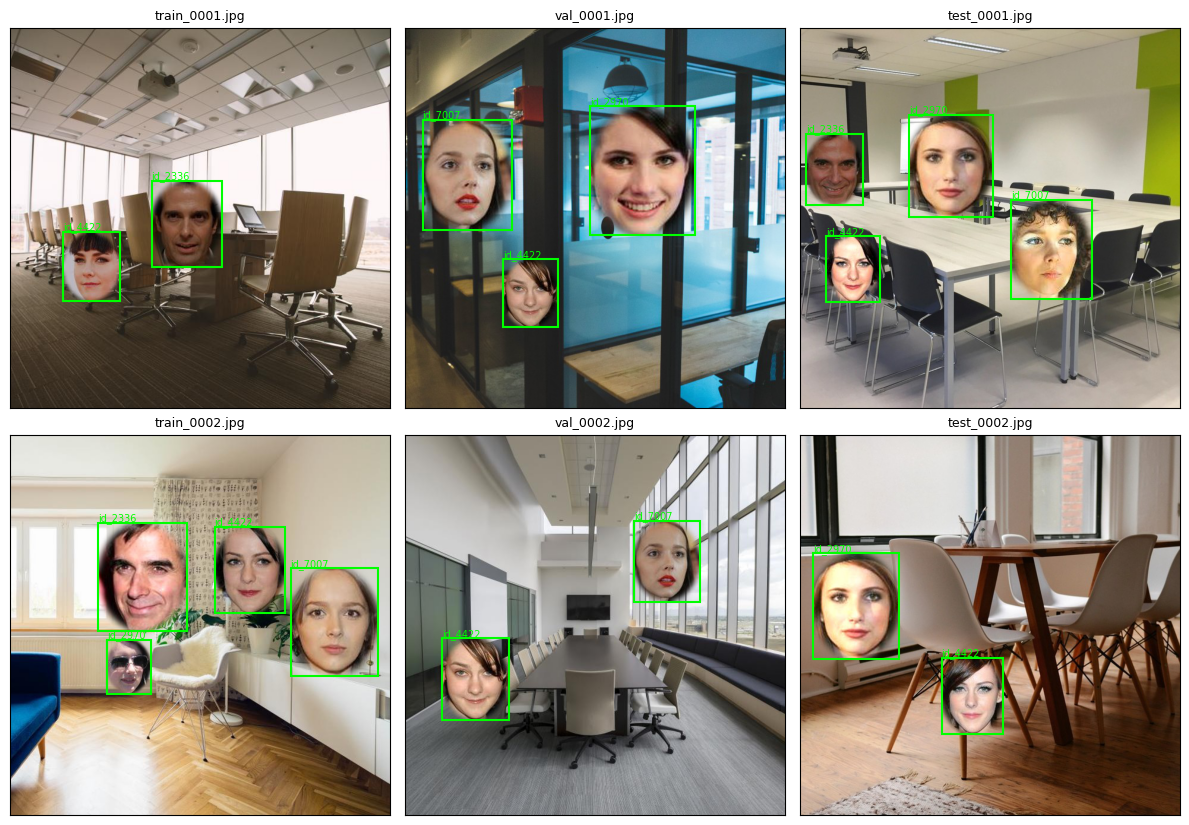

In [13]:
def draw_from_disk(ax, split, name):
    image = Image.open(syn.DET_DIR / "images" / split / f"{name}.jpg")
    ax.imshow(image)
    for line in (syn.DET_DIR / "labels" / split / f"{name}.txt").read_text().split("\n"):
        if not line:
            continue
        label, xc, yc, w, h = line.split()
        xc, yc, w, h = (float(v) * syn.IMG_SIZE for v in (xc, yc, w, h))
        ax.add_patch(plt.Rectangle((xc - w / 2, yc - h / 2), w, h,
                                   fill=False, edgecolor="lime", linewidth=1.5))
        ax.text(xc - w / 2, max(yc - h / 2 - 4, 12), syn.CLASS_NAMES[int(label)],
                color="lime", fontsize=7)
    ax.set_title(f"{name}.jpg", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

samples = [(s, f"{s}_{k:04d}") for s in syn.SPLITS for k in (1, 2)]
fig, axes = plt.subplots(2, 3, figsize=(12, 8.4))
for ax, (split, name) in zip(axes.T.flat, samples):
    draw_from_disk(ax, split, name)
fig.tight_layout()
syn.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(syn.RESULTS_DIR / "sample_annotations.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Task 2: Augmentation

Looking at Augmentation libraries, it seems that the standard library used is ImageDataGenerator from TensorFlow. However, because we are working with bounding boxes, this is not appropriate for our case - any transforms that occur will not be applied to the bounding boxes as well. Instead, the alternative we are using is Albumentations, an augmentation library which includes support for Yolo5 format, which is the format our bounding boxes are in.

Code based on Albumentation documentation from https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/


**Part A: Formatting the data correctly for Augmentation**

In [67]:
import numpy as np
def returnImageClassAndBox (split, name):
    img_dir = syn.DET_DIR / "images" / split
    lbl_dir = syn.DET_DIR / "labels" / split

    # Set up the dataset  appropriately
    image = cv2.imread(f"{img_dir}/{name}.jpg")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    rows = np.loadtxt(f"{lbl_dir}/{name}.txt", dtype=np.float32, ndmin=2)
    class_ids = rows[:, 0].astype(int).tolist()
    boxes = rows[:, 1:]  # [x_center, y_center, width, height], normalized

     # YOLO -> corner coordinates
    x_center = boxes[:, 0]
    y_center = boxes[:, 1]
    width = boxes[:, 2]
    height = boxes[:, 3]

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    # Clip actual box boundaries
    x_min = np.clip(x_min, 0.0, 1.0)
    y_min = np.clip(y_min, 0.0, 1.0)
    x_max = np.clip(x_max, 0.0, 1.0)
    y_max = np.clip(y_max, 0.0, 1.0)

    # Corner coordinates -> YOLO
    boxes = np.column_stack([
        (x_min + x_max) / 2,
        (y_min + y_max) / 2,
        x_max - x_min,
        y_max - y_min
    ])

    return image, boxes.tolist(), class_ids

**Part B: Augmentation**
For the actual augmentation pipeline, Albumentations suggests to take care in choosing augmentations for your dataset. For instance, a horizontal flip would not work for something like an alphabet detection algorithm, and converting an apple to grayscale would get rid of vital information inherent in its color.

For our purposes, we want the detection algorithm to detect our celebrities even when there is low light or a rotated or cropped face. Therefore, we will need most of the Augmentation pipeline laid out by Albumentations. 

The pipeline is as follows: 
1. Size Normalization — Crop or resize first (always)
2. Basic Geometric Invariances — HorizontalFlip, SquareSymmetry for aerial/medical
3. Dropout/Occlusion — CoarseDropout, ConstrainedCoarseDropout (high impact!)
4. Reduce Color Dependence — ToGray, ChannelDropout (if needed)
5. Affine Transformations — Affine for scale/rotation
6. Domain-Specific — Specialized transforms for your use case
7. Normalization — Standard or sample-specific (always last)

Of this pipeline, we are not using normalization (as it is unneeded, as the data is not going straight to an ML model, but is instead being saved back as an image). There is also no need for domain-specific transforms - the standard augmentations of cropping, flipping, dropouts, grayscale/brightness reduction, and rotations should be plenty. 

In [99]:
# !pip install albumentations

In [100]:
# Set up augmentation pipeline
import albumentations as A
import cv2
import numpy as np

train_transform = A.Compose([
    A.RandomCrop(width=450, height=450, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.CoarseDropout(num_holes_range=(3, 8),
                    hole_height_range=(0.05, 0.15),
                    hole_width_range=(0.05, 0.15), p=0.5),
    A.ToGray(p=0.2),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(
        scale=(0.8, 1.2),
        translate_percent=(-0.1, 0.1),
        rotate=(-15, 15),
        shear=(-5, 5),
        p=0.5
    ),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3,  # discard boxes with less than 30% visible
), seed=137)

In [101]:
import numpy as np

# Iterate through all made images - make a random augmentation for each. 
N_IMAGES = {"train": 300, "val": 100, "test": 100}

for i, (split, n) in enumerate(N_IMAGES.items()):
    for k in range(1, n + 1):
        # Setup name + directory variables
        name = f"{split}_{k:04d}"
        image, boxes, class_ids = returnImageClassAndBox(split, name)
        img_dir = syn.DET_DIR / "images" / split
        lbl_dir = syn.DET_DIR / "labels" / split

        # Augment
        result = train_transform(image=image, bboxes=boxes, class_labels=class_ids)
        augmented_image = result['image']
        augmented_bboxes = result['bboxes']
        augmented_labels = result['class_labels']

        # Save image + labels
        save_name = f"{split}_aug_{k:04d}"
        Image.fromarray(augmented_image).save(
            img_dir / f"{save_name}.jpg",
            quality=90,
        )
        
        lines = [
            f"{label} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
            for label, (xc, yc, bw, bh)
            in zip(result["class_labels"], result["bboxes"])
        ]
        (lbl_dir / f"{save_name}.txt").write_text("\n".join(lines) + "\n")

**Part C: Verify Output**
Four random augmented images are loaded, and the corresponding boundary boxes are drawn on each image. This is a visual sanity check that the augmentation worked, and that the boundary boxes still accurately describe the faces they label.

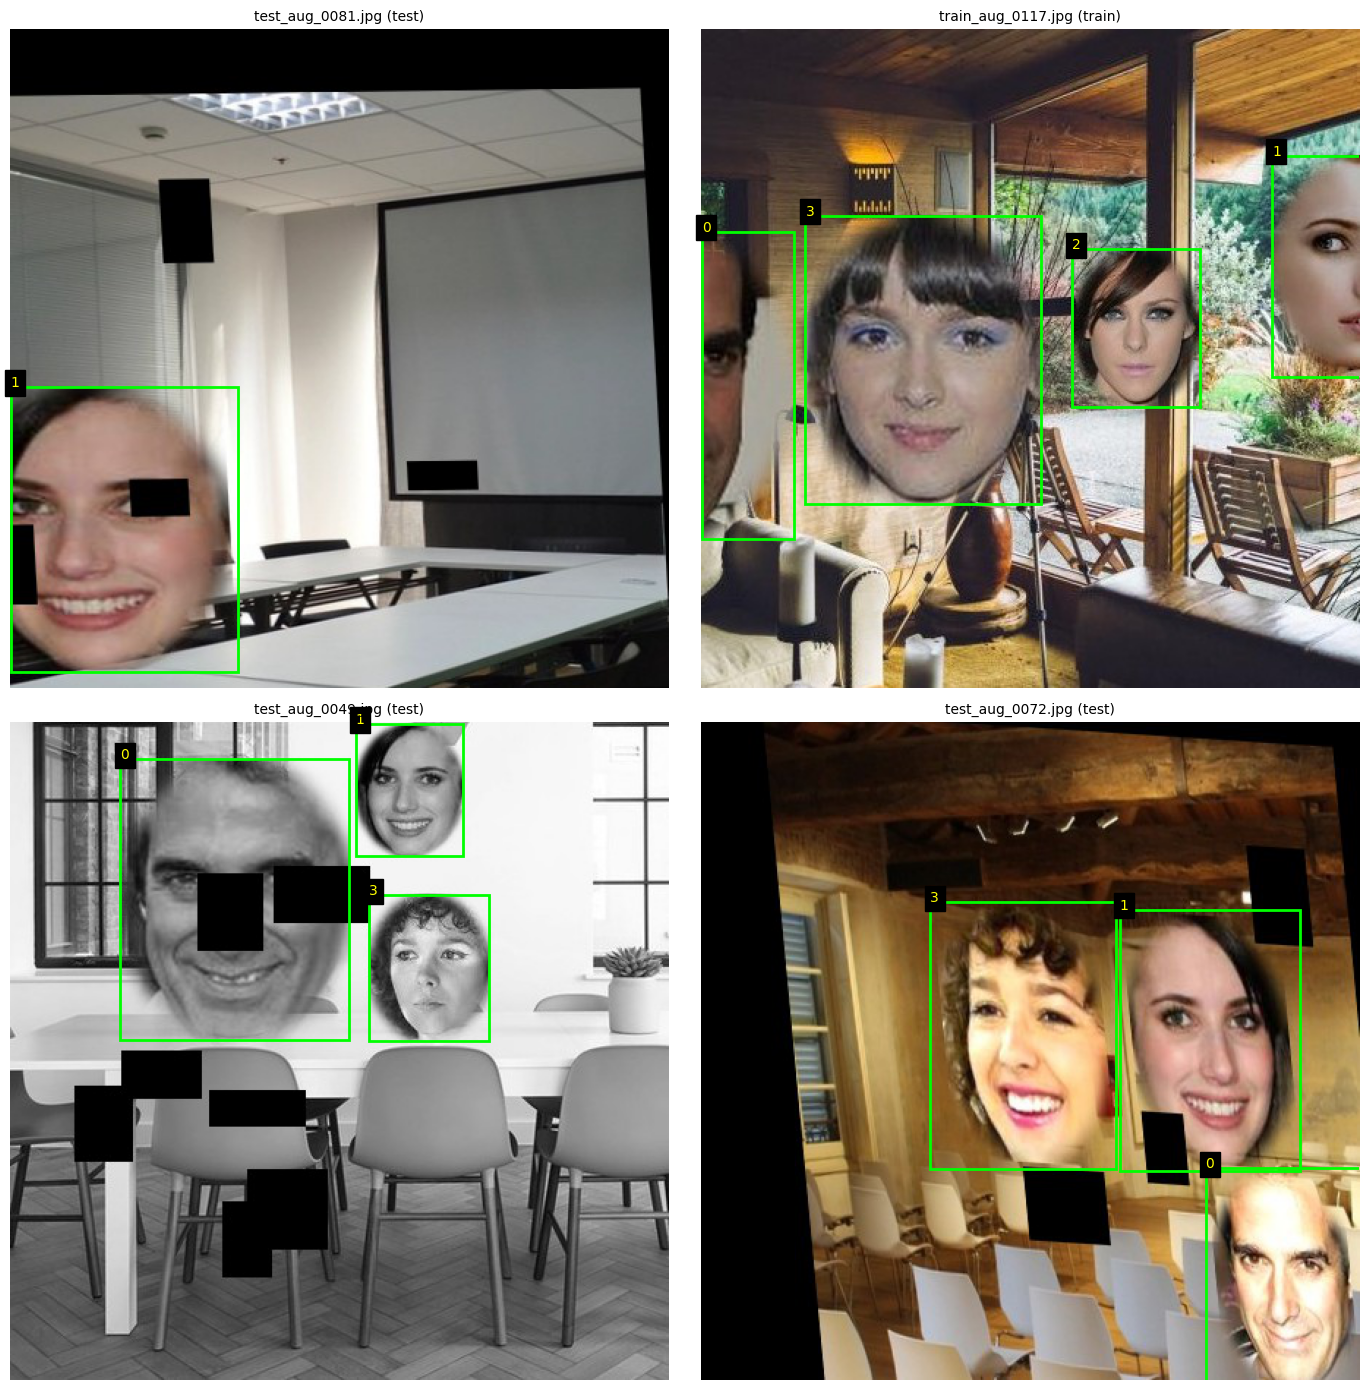

In [102]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Take a random 4 augmented images and write box around the faces.
N_IMAGES = {"train": 300, "val": 100, "test": 100}
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flat

for ax in axes:
    rand_split = random.choice(list(N_IMAGES))
    rand_num = random.randint(1, N_IMAGES[rand_split])
    save_name = f"{rand_split}_aug_{rand_num:04d}"

    img_dir = syn.DET_DIR / "images" / rand_split
    lbl_dir = syn.DET_DIR / "labels" / rand_split
    img_path = img_dir / f"{save_name}.jpg"
    label_path = lbl_dir / f"{save_name}.txt"

    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    ax.axis("off")

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue

            cls, xc, yc, bw, bh = map(float, parts)
            x = (xc - bw / 2) * w
            y = (yc - bh / 2) * h

            ax.add_patch(patches.Rectangle(
                (x, y), bw * w, bh * h,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))
            ax.text(
                x, y, str(int(cls)),
                color="yellow", fontsize=10, backgroundcolor="black"
            )

    ax.set_title(f"{img_path.name} ({rand_split})", fontsize=10)

plt.tight_layout()
plt.show()

---
## Task 3: Verification + Visuals
